# Computer Vision Lab
## Hough Transform for Line and Circle Detection

### Name: Muhammad Hamza Habib  
### Course: Computer Vision Lab  
### Lab: Hough Transform

## Objectives
- Understand Hough Transform
- Detect lines using Hough Line Transform
- Detect circles using Hough Circle Transform
- Visualize accumulator voting
- Apply in real-world scenarios

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# helper function to display images
def show(title, img, cmap=None):
    plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis("off")
    plt.show()

# Activities

# Activity 01: Load Image

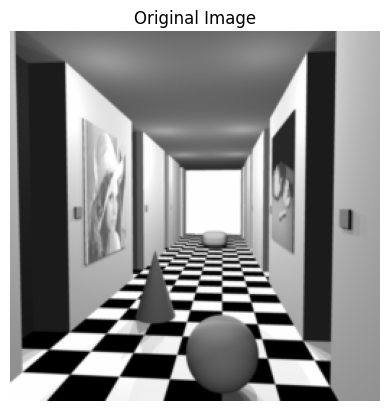

In [3]:
img = cv2.imread("E:\\vs code\\git\\Computer Vision\\Lab_07_hough_transformations\\shapes.jpeg")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

show("Original Image", img_rgb)

# Activity 02: Edge Detetion

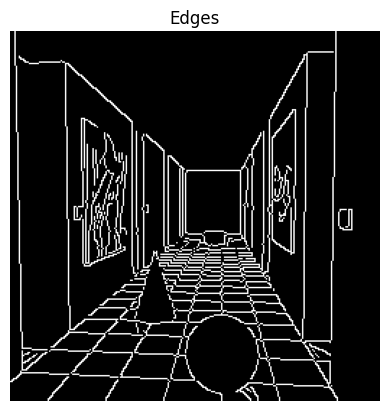

In [4]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
edges = cv2.Canny(gray, 100, 200)

show("Edges", edges, cmap="gray")

# Activity 03: Hough Line Transform

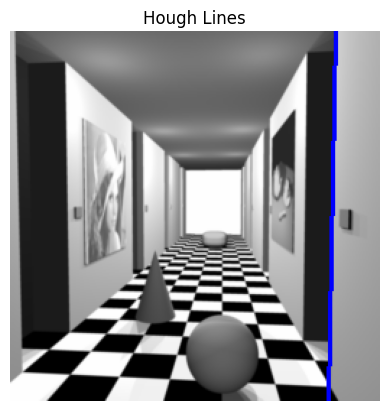

In [5]:
line_img = img.copy()
lines = cv2.HoughLines(edges, 1, np.pi/180, 150)

if lines is not None:
    for rho, theta in lines[:,0]:
        a, b = np.cos(theta), np.sin(theta)
        x0, y0 = a*rho, b*rho
        x1 = int(x0 + 1000*(-b))
        y1 = int(y0 + 1000*(a))
        x2 = int(x0 - 1000*(-b))
        y2 = int(y0 - 1000*(a))
        cv2.line(line_img, (x1,y1), (x2,y2), (255,0,0), 2)

show("Hough Lines", cv2.cvtColor(line_img, cv2.COLOR_BGR2RGB))

# Activity 04: Accumulator Voting

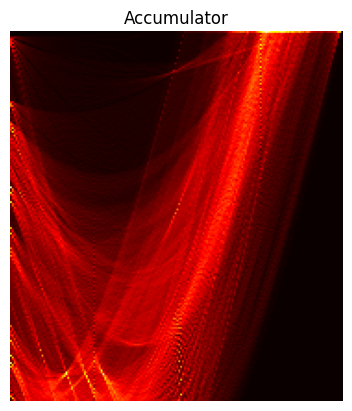

In [6]:
acc = np.zeros((200,180))

y_idx, x_idx = np.nonzero(edges)

for i in range(len(x_idx)):
    x, y = x_idx[i], y_idx[i]
    for theta in range(180):
        rho = int(x*np.cos(np.deg2rad(theta)) + y*np.sin(np.deg2rad(theta)))
        if 0 <= rho < 200:
            acc[rho, theta] += 1

show("Accumulator", acc, cmap="hot")

# Activity 05: Probabilistic Hough

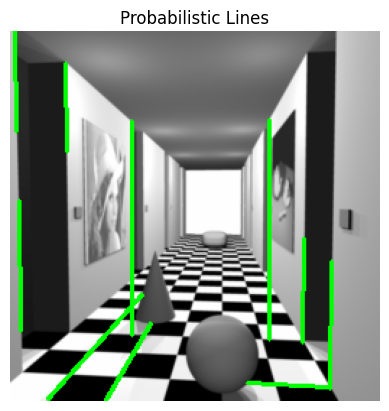

In [7]:
p_img = img.copy()

lines = cv2.HoughLinesP(edges,1,np.pi/180,100,minLineLength=50,maxLineGap=10)

if lines is not None:
    for x1,y1,x2,y2 in lines[:,0]:
        cv2.line(p_img,(x1,y1),(x2,y2),(0,255,0),2)

show("Probabilistic Lines", cv2.cvtColor(p_img, cv2.COLOR_BGR2RGB))

# Activity 06: Circle Detection

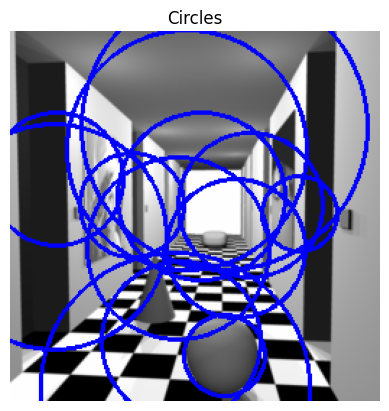

In [8]:
c_img = img.copy()

circles = cv2.HoughCircles(gray, cv2.HOUGH_GRADIENT,1,30,
                           param1=100,param2=30,
                           minRadius=20,maxRadius=100)

if circles is not None:
    circles = np.uint16(np.around(circles))
    for x,y,r in circles[0]:
        cv2.circle(c_img,(x,y),r,(255,0,0),2)

show("Circles", cv2.cvtColor(c_img, cv2.COLOR_BGR2RGB))

# Activity 07: Detect Multiple Circles (Coins)

Total Coins Detected: 22


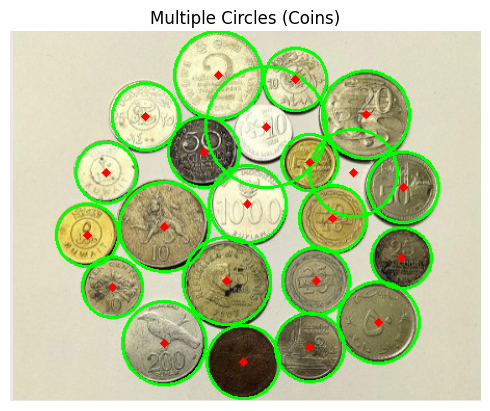

In [9]:
img = cv2.imread("E:\\vs code\\git\\Computer Vision\\Lab_07_hough_transformations\\coin.jpg")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray = cv2.medianBlur(gray, 5)

circles = cv2.HoughCircles(
    gray,
    cv2.HOUGH_GRADIENT,
    dp=1,
    minDist=40,
    param1=100,
    param2=30,
    minRadius=10,
    maxRadius=60
)

output = img.copy()
count = 0

if circles is not None:
    circles = np.uint16(np.around(circles))
    count = len(circles[0])
    
    for x, y, r in circles[0]:
        cv2.circle(output, (x, y), r, (0, 255, 0), 2)
        cv2.circle(output, (x, y), 2, (0, 0, 255), 3)

print("Total Coins Detected:", count)

show("Multiple Circles (Coins)", cv2.cvtColor(output, cv2.COLOR_BGR2RGB))

# Activity 08: Tune Parameters

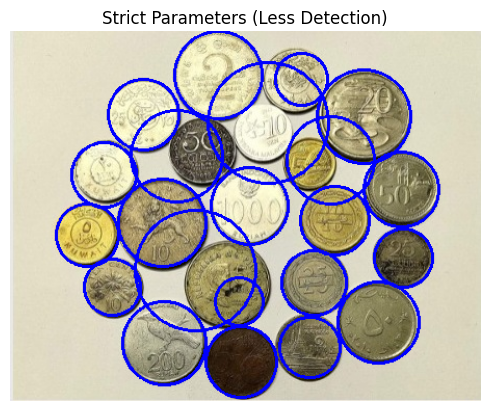

In [11]:
# Low Detection

img = cv2.imread("E:\\vs code\\git\\Computer Vision\\Lab_07_hough_transformations\\coin.jpg")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

circles = cv2.HoughCircles(
    gray,
    cv2.HOUGH_GRADIENT,
    dp=1,
    minDist=50,
    param1=150,   # High threshold
    param2=40,    # Strict detection
    minRadius=10,
    maxRadius=60
)

output = img.copy()

if circles is not None:
    circles = np.uint16(np.around(circles))
    for x,y,r in circles[0]:
        cv2.circle(output,(x,y),r,(255,0,0),2)

show("Strict Parameters (Less Detection)", cv2.cvtColor(output, cv2.COLOR_BGR2RGB))

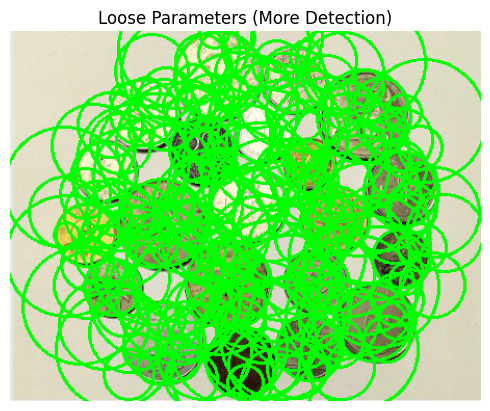

In [12]:
# High Detection

circles = cv2.HoughCircles(
    gray,
    cv2.HOUGH_GRADIENT,
    dp=1,
    minDist=20,
    param1=80,    # Lower threshold
    param2=20,    # More sensitive
    minRadius=10,
    maxRadius=60
)

output2 = img.copy()

if circles is not None:
    circles = np.uint16(np.around(circles))
    for x,y,r in circles[0]:
        cv2.circle(output2,(x,y),r,(0,255,0),2)

show("Loose Parameters (More Detection)", cv2.cvtColor(output2, cv2.COLOR_BGR2RGB))

# Activity 09: Lane Detection (Real-world)

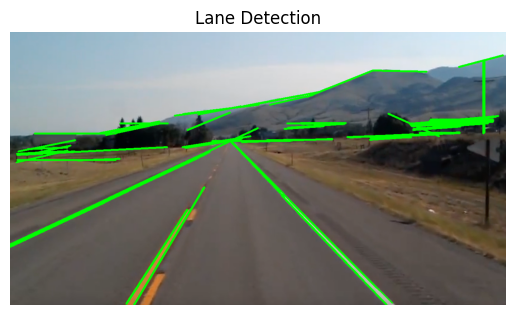

In [13]:
img = cv2.imread("E:\\vs code\\git\\Computer Vision\\Lab_07_hough_transformations\\lane.jpg")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

edges = cv2.Canny(gray, 50, 150)

lines = cv2.HoughLinesP(
    edges,
    1,
    np.pi/180,
    threshold=50,
    minLineLength=100,
    maxLineGap=50
)

output = img.copy()

if lines is not None:
    for x1,y1,x2,y2 in lines[:,0]:
        cv2.line(output,(x1,y1),(x2,y2),(0,255,0),3)

show("Lane Detection", cv2.cvtColor(output, cv2.COLOR_BGR2RGB))

# Activity 10: Compare Line vs Circle Voting

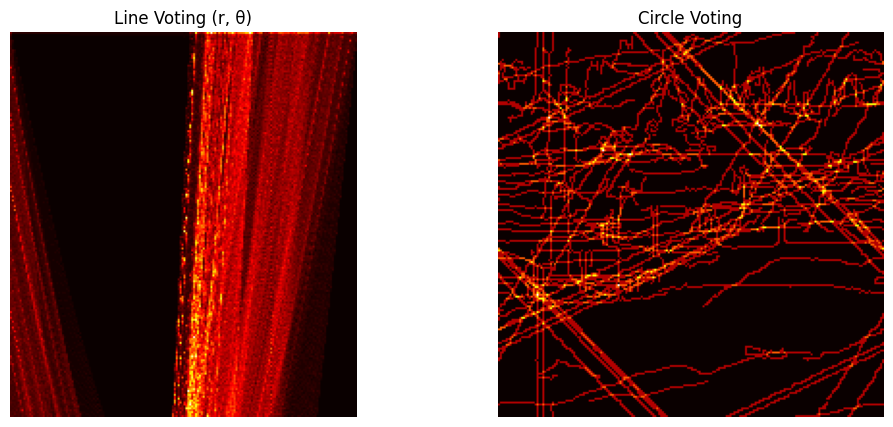

In [14]:
# Line Voting (Accumulator)
accumulator = np.zeros((200, 180))

y_idxs, x_idxs = np.nonzero(edges)

for i in range(len(x_idxs)):
    x = x_idxs[i]
    y = y_idxs[i]
    
    for theta in range(180):
        rho = int(x*np.cos(np.deg2rad(theta)) + y*np.sin(np.deg2rad(theta)))
        if 0 <= rho < 200:
            accumulator[rho, theta] += 1

# Circle Voting (Simple Visualization)
circle_votes = np.zeros((200, 200))

for y, x in zip(y_idxs, x_idxs):
    circle_votes[y % 200, x % 200] += 1

# Show both
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(accumulator, cmap='hot')
plt.title("Line Voting (r, θ)")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(circle_votes, cmap='hot')
plt.title("Circle Voting")
plt.axis("off")

plt.show()

# Graded Tasks


In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def show(title, img, cmap=None):
    plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis("off")
    plt.show()

# Task 01: Whiteboard Edges

# Task 01: Whiteboard Edges

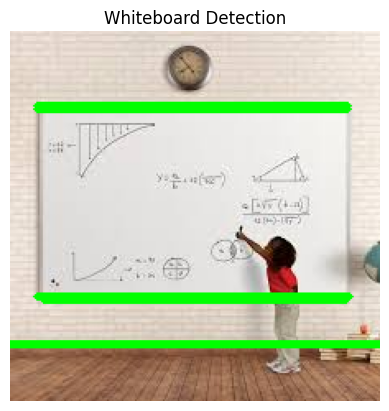

In [103]:
img = cv2.imread("E:\\vs code\\git\\Computer Vision\\Lab_07_hough_transformations\\whiteboard.jpg")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
edges = cv2.Canny(gray, 50, 150)

lines = cv2.HoughLinesP(edges, 1, np.pi/180, 170, minLineLength=100, maxLineGap=100)

if lines is not None:
    for x1,y1,x2,y2 in lines[:,0]:
        cv2.line(img,(x1,y1),(x2,y2),(0,255,0),4)

show("Whiteboard Detection", cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

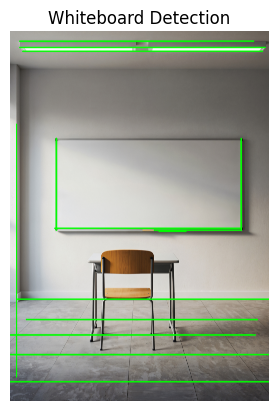

In [132]:
img = cv2.imread("E:\\vs code\\git\\Computer Vision\\Lab_07_hough_transformations\\whiteboard2.jpg")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
edges = cv2.Canny(gray, 50, 150)

lines = cv2.HoughLinesP(edges, 0.6, np.pi/360, 800, minLineLength=200, maxLineGap=1000)

if lines is not None:
    for x1,y1,x2,y2 in lines[:,0]:
        cv2.line(img,(x1,y1),(x2,y2),(0,255,0),30)

show("Whiteboard Detection", cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

# Task 02: Parking Lines

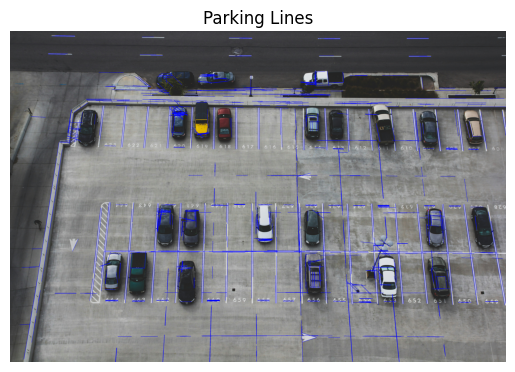

In [17]:
img = cv2.imread("E:\\vs code\\git\\Computer Vision\\Lab_07_hough_transformations\\parking.jpg")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
edges = cv2.Canny(gray, 50, 150)

lines = cv2.HoughLinesP(edges,1,np.pi/180,80,minLineLength=100,maxLineGap=20)

for x1,y1,x2,y2 in lines[:,0]:
    cv2.line(img,(x1,y1),(x2,y2),(255,0,0),2)

show("Parking Lines", cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

# Task 03: Coin counter

Number of Coins: 22


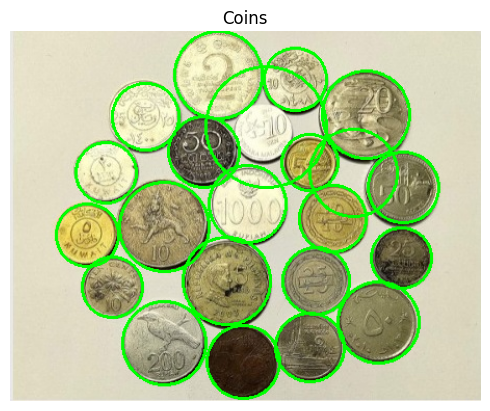

In [18]:
img = cv2.imread("E:\\vs code\\git\\Computer Vision\\Lab_07_hough_transformations\\coin.jpg")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray = cv2.medianBlur(gray,5)

circles = cv2.HoughCircles(gray, cv2.HOUGH_GRADIENT,1,40,
                           param1=100,param2=30,
                           minRadius=10,maxRadius=60)

count = 0

if circles is not None:
    circles = np.uint16(np.around(circles))
    count = len(circles[0])
    for x,y,r in circles[0]:
        cv2.circle(img,(x,y),r,(0,255,0),2)

print("Number of Coins:", count)
show("Coins", cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

# Task 04: Bottle Caps

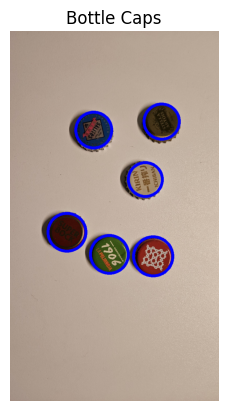

In [91]:
img = cv2.imread("E:\\vs code\\git\\Computer Vision\\Lab_07_hough_transformations\\bottle_caps.png")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray = cv2.medianBlur(gray,5)

circles = cv2.HoughCircles(gray, cv2.HOUGH_GRADIENT,1,70,
                           param1=100,param2=25,
                           minRadius=10,maxRadius=80)

if circles is not None:
    circles = np.uint16(np.around(circles))
    for x,y,r in circles[0]:
        cv2.circle(img,(x,y),r,(255,0,0),8)

show("Bottle Caps", cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

# Task 05: Sports Ground

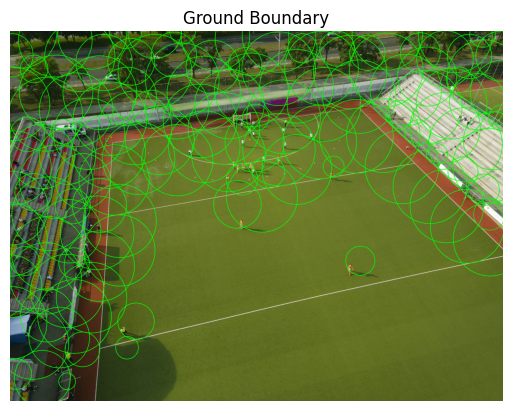

In [84]:
img = cv2.imread("E:\\vs code\\git\\Computer Vision\\Lab_07_hough_transformations\\sports_ground_02.jpg")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

circles = cv2.HoughCircles(
    gray,
    cv2.HOUGH_GRADIENT,
    dp=1.2,
    minDist=200,
    param1=100,
    param2=30,
    minRadius=50,
    maxRadius=300
)

if circles is not None:
    circles = np.uint16(np.around(circles))
    for x,y,r in circles[0]:
        cv2.circle(img,(x,y),r,(0,255,0),3)

show("Ground Boundary", cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

# Task 06: Lane Detection

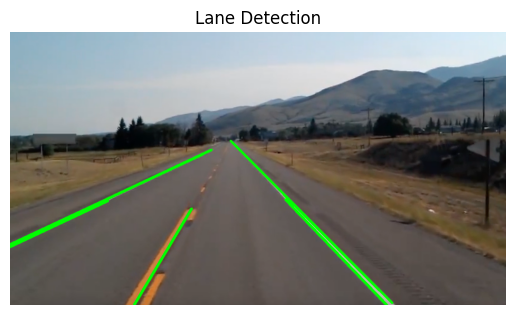

In [82]:
img = cv2.imread("E:\\vs code\\git\\Computer Vision\\Lab_07_hough_transformations\\lane.jpg")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
edges = cv2.Canny(gray,50,150)

lines = cv2.HoughLinesP(edges,0.2,np.pi/180,50,minLineLength=180,maxLineGap=31)

for x1,y1,x2,y2 in lines[:,0]:
    cv2.line(img,(x1,y1),(x2,y2),(0,255,0),5)

show("Lane Detection", cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

# Task 07: CD/DVD Detection

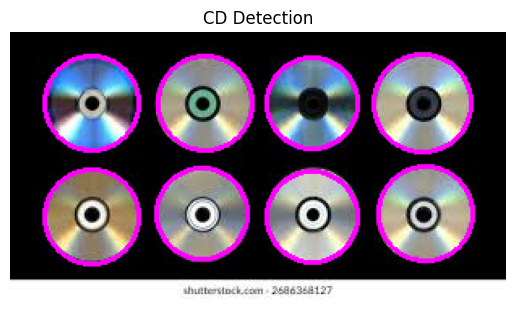

In [59]:
img = cv2.imread("E:\\vs code\\git\\Computer Vision\\Lab_07_hough_transformations\\CD.jpg")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

circles = cv2.HoughCircles(gray, cv2.HOUGH_GRADIENT,1,50,
                           param1=100,param2=30,
                           minRadius=15,maxRadius=70)

if circles is not None:
    circles = np.uint16(np.around(circles))
    for x,y,r in circles[0]:
        cv2.circle(img,(x,y),r,(255,0,255),2)

show("CD Detection", cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

# Task 08: Solar Panel Lines

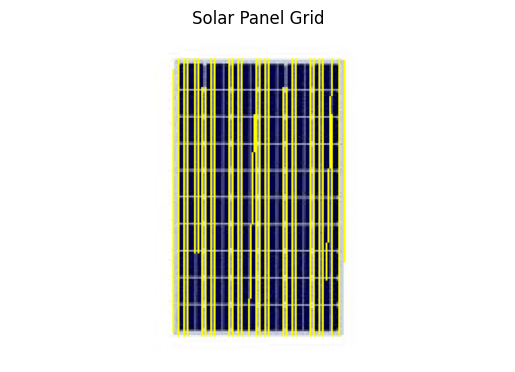

In [56]:
img = cv2.imread("E:\\vs code\\git\\Computer Vision\\Lab_07_hough_transformations\\solar_panel.jpg")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
edges = cv2.Canny(gray,50,150)

lines = cv2.HoughLinesP(edges,1,np.pi/180,80,minLineLength=100,maxLineGap=10)

for x1,y1,x2,y2 in lines[:,0]:
    cv2.line(img,(x1,y1),(x2,y2),(0,255,255),1)

show("Solar Panel Grid", cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

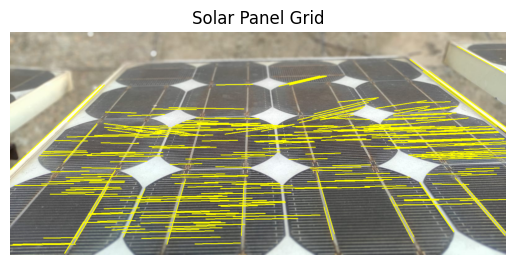

In [34]:
img = cv2.imread("E:\\vs code\\git\\Computer Vision\\Lab_07_hough_transformations\\solar_panel.png")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
edges = cv2.Canny(gray,50,150)

lines = cv2.HoughLinesP(edges,1,np.pi/180,80,minLineLength=100,maxLineGap=10)

for x1,y1,x2,y2 in lines[:,0]:
    cv2.line(img,(x1,y1),(x2,y2),(0,255,255),2)

show("Solar Panel Grid", cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

# Task 09: Clock Detection

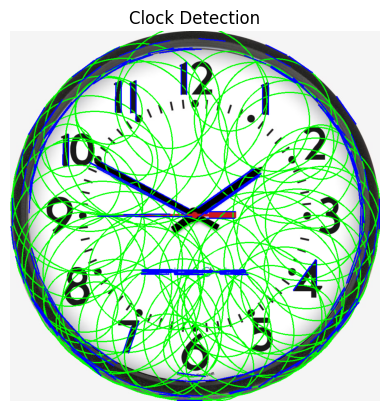

In [35]:
img = cv2.imread("E:\\vs code\\git\\Computer Vision\\Lab_07_hough_transformations\\clock1.jpg")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Circle (clock boundary)
circles = cv2.HoughCircles(gray, cv2.HOUGH_GRADIENT,1,50,
                           param1=100,param2=30,
                           minRadius=50,maxRadius=200)

if circles is not None:
    circles = np.uint16(np.around(circles))
    for x,y,r in circles[0]:
        cv2.circle(img,(x,y),r,(0,255,0),2)

# Lines (clock hands)
edges = cv2.Canny(gray,50,150)
lines = cv2.HoughLinesP(edges,1,np.pi/180,50,minLineLength=50,maxLineGap=10)

if lines is not None:
    for x1,y1,x2,y2 in lines[:,0]:
        cv2.line(img,(x1,y1),(x2,y2),(255,0,0),2)

show("Clock Detection", cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

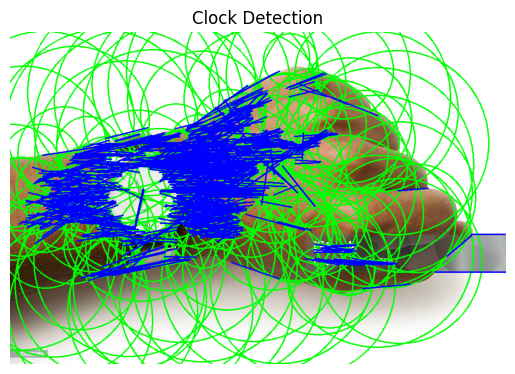

In [36]:
img = cv2.imread("E:\\vs code\\git\\Computer Vision\\Lab_07_hough_transformations\\handWatch.jpg")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Circle (clock boundary)
circles = cv2.HoughCircles(gray, cv2.HOUGH_GRADIENT,1,50,
                           param1=100,param2=30,
                           minRadius=50,maxRadius=200)

if circles is not None:
    circles = np.uint16(np.around(circles))
    for x,y,r in circles[0]:
        cv2.circle(img,(x,y),r,(0,255,0),2)

# Lines (clock hands)
edges = cv2.Canny(gray,50,150)
lines = cv2.HoughLinesP(edges,1,np.pi/180,50,minLineLength=50,maxLineGap=10)

if lines is not None:
    for x1,y1,x2,y2 in lines[:,0]:
        cv2.line(img,(x1,y1),(x2,y2),(255,0,0),2)

show("Clock Detection", cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

# Task 10: Medical Cells

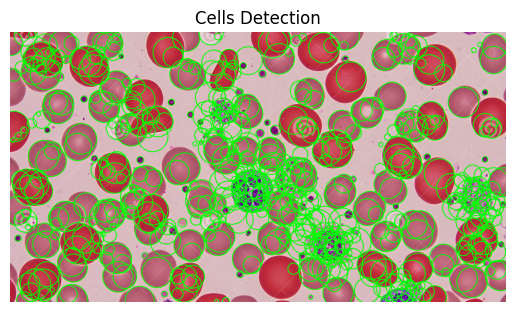

In [55]:
img = cv2.imread("E:\\vs code\\git\\Computer Vision\\Lab_07_hough_transformations\\blood_cells.jpg")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray = cv2.medianBlur(gray,5)

circles = cv2.HoughCircles(gray, cv2.HOUGH_GRADIENT,1,20,
                           param1=70,param2=15,
                           minRadius=5,maxRadius=50)

if circles is not None:
    circles = np.uint16(np.around(circles))
    for x,y,r in circles[0]:
        cv2.circle(img,(x,y),r,(0,255,0),2)

show("Cells Detection", cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

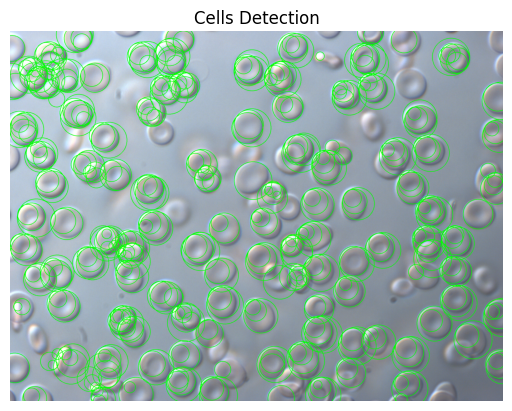

In [52]:
img = cv2.imread("E:\\vs code\\git\\Computer Vision\\Lab_07_hough_transformations\\red_blood_cells.jpg")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray = cv2.medianBlur(gray,5)

circles = cv2.HoughCircles(gray, cv2.HOUGH_GRADIENT,1,20,
                           param1=70,param2=15,
                           minRadius=20,maxRadius=100)

if circles is not None:
    circles = np.uint16(np.around(circles))
    for x,y,r in circles[0]:
        cv2.circle(img,(x,y),r,(0,255,0),2)

show("Cells Detection", cv2.cvtColor(img, cv2.COLOR_BGR2RGB))